In [1]:
begin
    using Pkg
    dev_folder = @__DIR__
    Pkg.activate(dev_folder)
end

# ONLY run this block once to set up the development environment
# begin
#     pkg_folder = joinpath(dev_folder, "..")
#     Pkg.develop(path=pkg_folder)
#     Pkg.instantiate()
# end

Threads.nthreads()

  Activating project at `~/Realizibility_index/BindingAndCatalysis.jl/Examples`


24

In [2]:
using CairoMakie # for plotting, we use Makie backend, could also be GLMakie or WGLMakie...
using Revise
using BindingAndCatalysis # import the package


[ Info: Precompiling IJuliaReviseExt [b74c6c38-2542-566b-9b5f-490bff998244] (cache misses: wrong dep version loaded (2), incompatible header (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [11]:
model = let
    N = [2 1 -1]  # define stoichiometry matrix
    x_sym = [:A, :B, :ab] # Optional: define species symbols
    q_sym = [:tA, :tB] # Optional: define total concentration symbols
    K_sym = [:K12] # Optional: define binding constant symbols
    Bnc(N = N, x_sym=x_sym, q_sym=q_sym, K_sym=K_sym) # create Bnc model
end

----------Binding Network Summary:-------------
Number of species (n): 3
Number of conserved quantities (d): 2
Number of reactions (r): 1
L matrix: sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, 2, 1], 2, 3)
N matrix: sparse([1, 1, 1], [1, 2, 3], [2, 1, -1], 1, 3)
Direction of binding reactions: backward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

In [12]:
find_all_vertices!(model) # find all possible vertices

[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 4 regimes found and 4 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: Calculating vertices neighbor graph with qK change dir
[ Info: Finished.


In [13]:
summary(model) # Now regime data is available

----------Binding Network Summary:-------------
Number of species (n): 3
Number of conserved quantities (d): 2
Number of reactions (r): 1
L matrix: sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, 2, 1], 2, 3)
N matrix: sparse([1, 1, 1], [1, 2, 3], [2, 1, -1], 1, 3)
Direction of binding reactions: backward
Catalysis involved: No
Regimes constructed: Yes
Number of regimes: 4
  - Invertible + Asymptotic: 3
  - Singular +  Asymptotic: 1
  - Invertible +  Non-Asymptotic: 0
  - Singular +  Non-Asymptotic: 0
-----------------------------------------------


In [14]:
vtx_grh = get_vertices_graph!(model)

BindingAndCatalysis.VertexGraph{Int64}(Bnc{Int64}(sparse([1, 1, 1], [1, 2, 3], [2, 1, -1], 1, 3), sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, 2, 1], 2, 3), 1, 3, 2, Symbolics.Num[A, B, ab], Symbolics.Num[tA, tB], Symbolics.Num[K12], nothing, BindingAndCatalysis.Regimes{Int64, BindingAndCatalysis.BindRegime, Vector{BindingAndCatalysis.BindRegime}}(Dict([1, 3] => 2, [3, 3] => 4, [1, 2] => 1, [3, 2] => 3), BindingAndCatalysis.BindRegime[BindingAndCatalysis.BindRegime{Float64, Int64}(Bnc{Int64}(#= circular reference @-4 =#), [1, 2], 1, true, sparse([1, 2], [1, 2], [1, 1], 2, 3), [0.0, 0.0], sparse([1, 3, 2, 3, 3], [1, 1, 2, 2, 3], [1, 2, 1, 1, -1], 3, 3), [0.0, 0.0, 0.0], sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, -1, -1], 2, 3), [-0.3010299956639812, 0.0], 0, sparse([1, 3, 2, 3, 3], [1, 1, 2, 2, 3], [1.0, 2.0, 1.0, 1.0, -1.0], 3, 3), [-0.0, -0.0, -0.0], nothing, nothing, nothing), BindingAndCatalysis.BindRegime{Float64, Int64}(Bnc{Int64}(#= circular reference @-4 =#), [1, 3], 2, true, nothin

In [22]:
r_g = better_path_finder(model, [1.0, 1.0])
conds = r_g.paths[1, 3][1].condition
show_condition_poly(conds; syms=[model.q_sym; model.K_sym],log_space=false)

Initializing regime graph...


1-element Vector{Symbolics.Num}:
 (2.0000000000000004(tB^1.0000000000000002)) > ((K12^2.355138688025663e-16)*tA)

In [16]:
siso = get_SISO_graph(model, :tA) # will give you a simple DiGraph

{4, 4} directed simple Int64 graph

In [17]:
pths = SISOPaths(model, :tB) # get all SISO paths for tS
summary(pths) # summary of the paths, including the path conditions and the asymptotic behavior of each path

Path 1         #1 → #3       Volume: 0.5014 ± 0.0022
Path 2         #2 → #4 → #3  Volume: 0.4986 ± 0.0022


[ Info: sources: [2, 1]
[ Info: sinks: [3]
[ Info: Start enumerating paths from sources to sinks. This may take a while if there are many paths.
[ Info: Total vertices to process in topological order: 4
[ Info: Finished enumerating paths. Now collecting paths from sources. Total sources: 2
[ Info: Start building polyhedra for edges (total: 3)
[ Info: Start building polyhedra for paths (total: 2)
[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 200000 samples.


In [18]:
logK=0
logE_rg = (-6,6)
logS_rg = (-6,6)
# total_points = 1e6 # points each dimension
pts_each_dim =1000



logx = begin
    data = Matrix{Vector{Float64}}(undef, pts_each_dim, pts_each_dim)
    
    # fill the first axis with chaning tS
    startqK = [logE_rg[1], logS_rg[1],  logK] # pass parameter in tE,tS, K order
    endqK = [logE_rg[1], logS_rg[2],logK]
    data[:,1] .= x_traj_with_qK_change(model,startqK,endqK; 
        input_logspace=true, output_logspace=true,npoints=pts_each_dim)[2]

    # fill the second axis with changing tE
    start_logS = range(logS_rg..., length=pts_each_dim)
    Threads.@threads for i in 1:pts_each_dim
        startqK = [logE_rg[1], start_logS[i],  logK] 
        endqK = [logE_rg[2], start_logS[i], logK]
        # start_logx = data[i,1]
        data[i,1:end] .= x_traj_with_qK_change(model, startqK, endqK; 
            # startlogx = start_logx, 
            input_logspace=true, output_logspace=true,npoints=pts_each_dim)[2]
    end
    data
end

# MM_C(Et,St,K) = Et*St/(St+K)
# logC_MM = log10.(
#     MM_C.(
#         exp10.(range(logS_rg...,pts_each_dim)),
#         exp10.(range(logE_rg...,pts_each_dim)')
#         ,1)
#     )

logx_rgm = let
    data = Matrix{Vector{Float64}}(undef, pts_each_dim,pts_each_dim)
    lgS = range(logS_rg..., length=pts_each_dim)
    lgE = range(logE_rg..., length=pts_each_dim)
    Threads.@threads for i in 1:pts_each_dim
        for j in 1:pts_each_dim
            logqK = [lgE[j], lgS[i], logK]
            data[i,j] = qK2x(model, logqK;input_logspace=true,output_logspace=true, use_vtx=true)
        end
    end
    data
end

1000×1000 Matrix{Vector{Float64}}:
 [-6.0, -6.0, -18.0]            …  [6.0, -18.0, -6.0]
 [-6.0, -5.98799, -17.988]         [6.0, -17.988, -5.98799]
 [-6.0, -5.97598, -17.976]         [6.0, -17.976, -5.97598]
 [-6.0, -5.96396, -17.964]         [6.0, -17.964, -5.96396]
 [-6.0, -5.95195, -17.952]         [6.0, -17.952, -5.95195]
 [-6.0, -5.93994, -17.9399]     …  [6.0, -17.9399, -5.93994]
 [-6.0, -5.92793, -17.9279]        [6.0, -17.9279, -5.92793]
 [-6.0, -5.91592, -17.9159]        [6.0, -17.9159, -5.91592]
 [-6.0, -5.9039, -17.9039]         [6.0, -17.9039, -5.9039]
 [-6.0, -5.89189, -17.8919]        [6.0, -17.8919, -5.89189]
 [-6.0, -5.87988, -17.8799]     …  [6.0, -17.8799, -5.87988]
 [-6.0, -5.86787, -17.8679]        [6.0, -17.8679, -5.86787]
 [-6.0, -5.85586, -17.8559]        [6.0, -17.8559, -5.85586]
 ⋮                              ⋱  
 [-6.08445, 5.86787, -6.30103]     [-0.0844489, 5.86787, 5.69897]
 [-6.09045, 5.87988, -6.30103]     [-0.0904549, 5.87988, 5.69897]
 [-6.09646, 5.89

In [19]:
# assign regimes according to different criteria.
col_asym_x = logx .|> x->assign_regime_x(model, x,input_logspace=true; asymptotic_only=true,return_idx=true)
col_nonasym_x = logx .|> x->assign_regime_x(model, x,input_logspace=true; asymptotic_only=false,return_idx=true)
col_asym_qK = logx .|> x->assign_regime_qK(model; x=x,input_logspace=true , asymptotic_only=true,return_idx=true) 
col_nonasym_qK = logx .|> x->assign_regime_qK(model; x=x,input_logspace=true , asymptotic_only=false,return_idx=true)


# find the boundary between different regimes.
bnds_asym_x = find_bounds(col_asym_x)
bnds_nonasym_x = find_bounds(col_nonasym_x)
bnds_asym_qK = find_bounds(col_asym_qK)
bnds_nonasym_qK = find_bounds(col_nonasym_qK)

cmap = get_color_map(col_nonasym_x)
print("Done")

Done

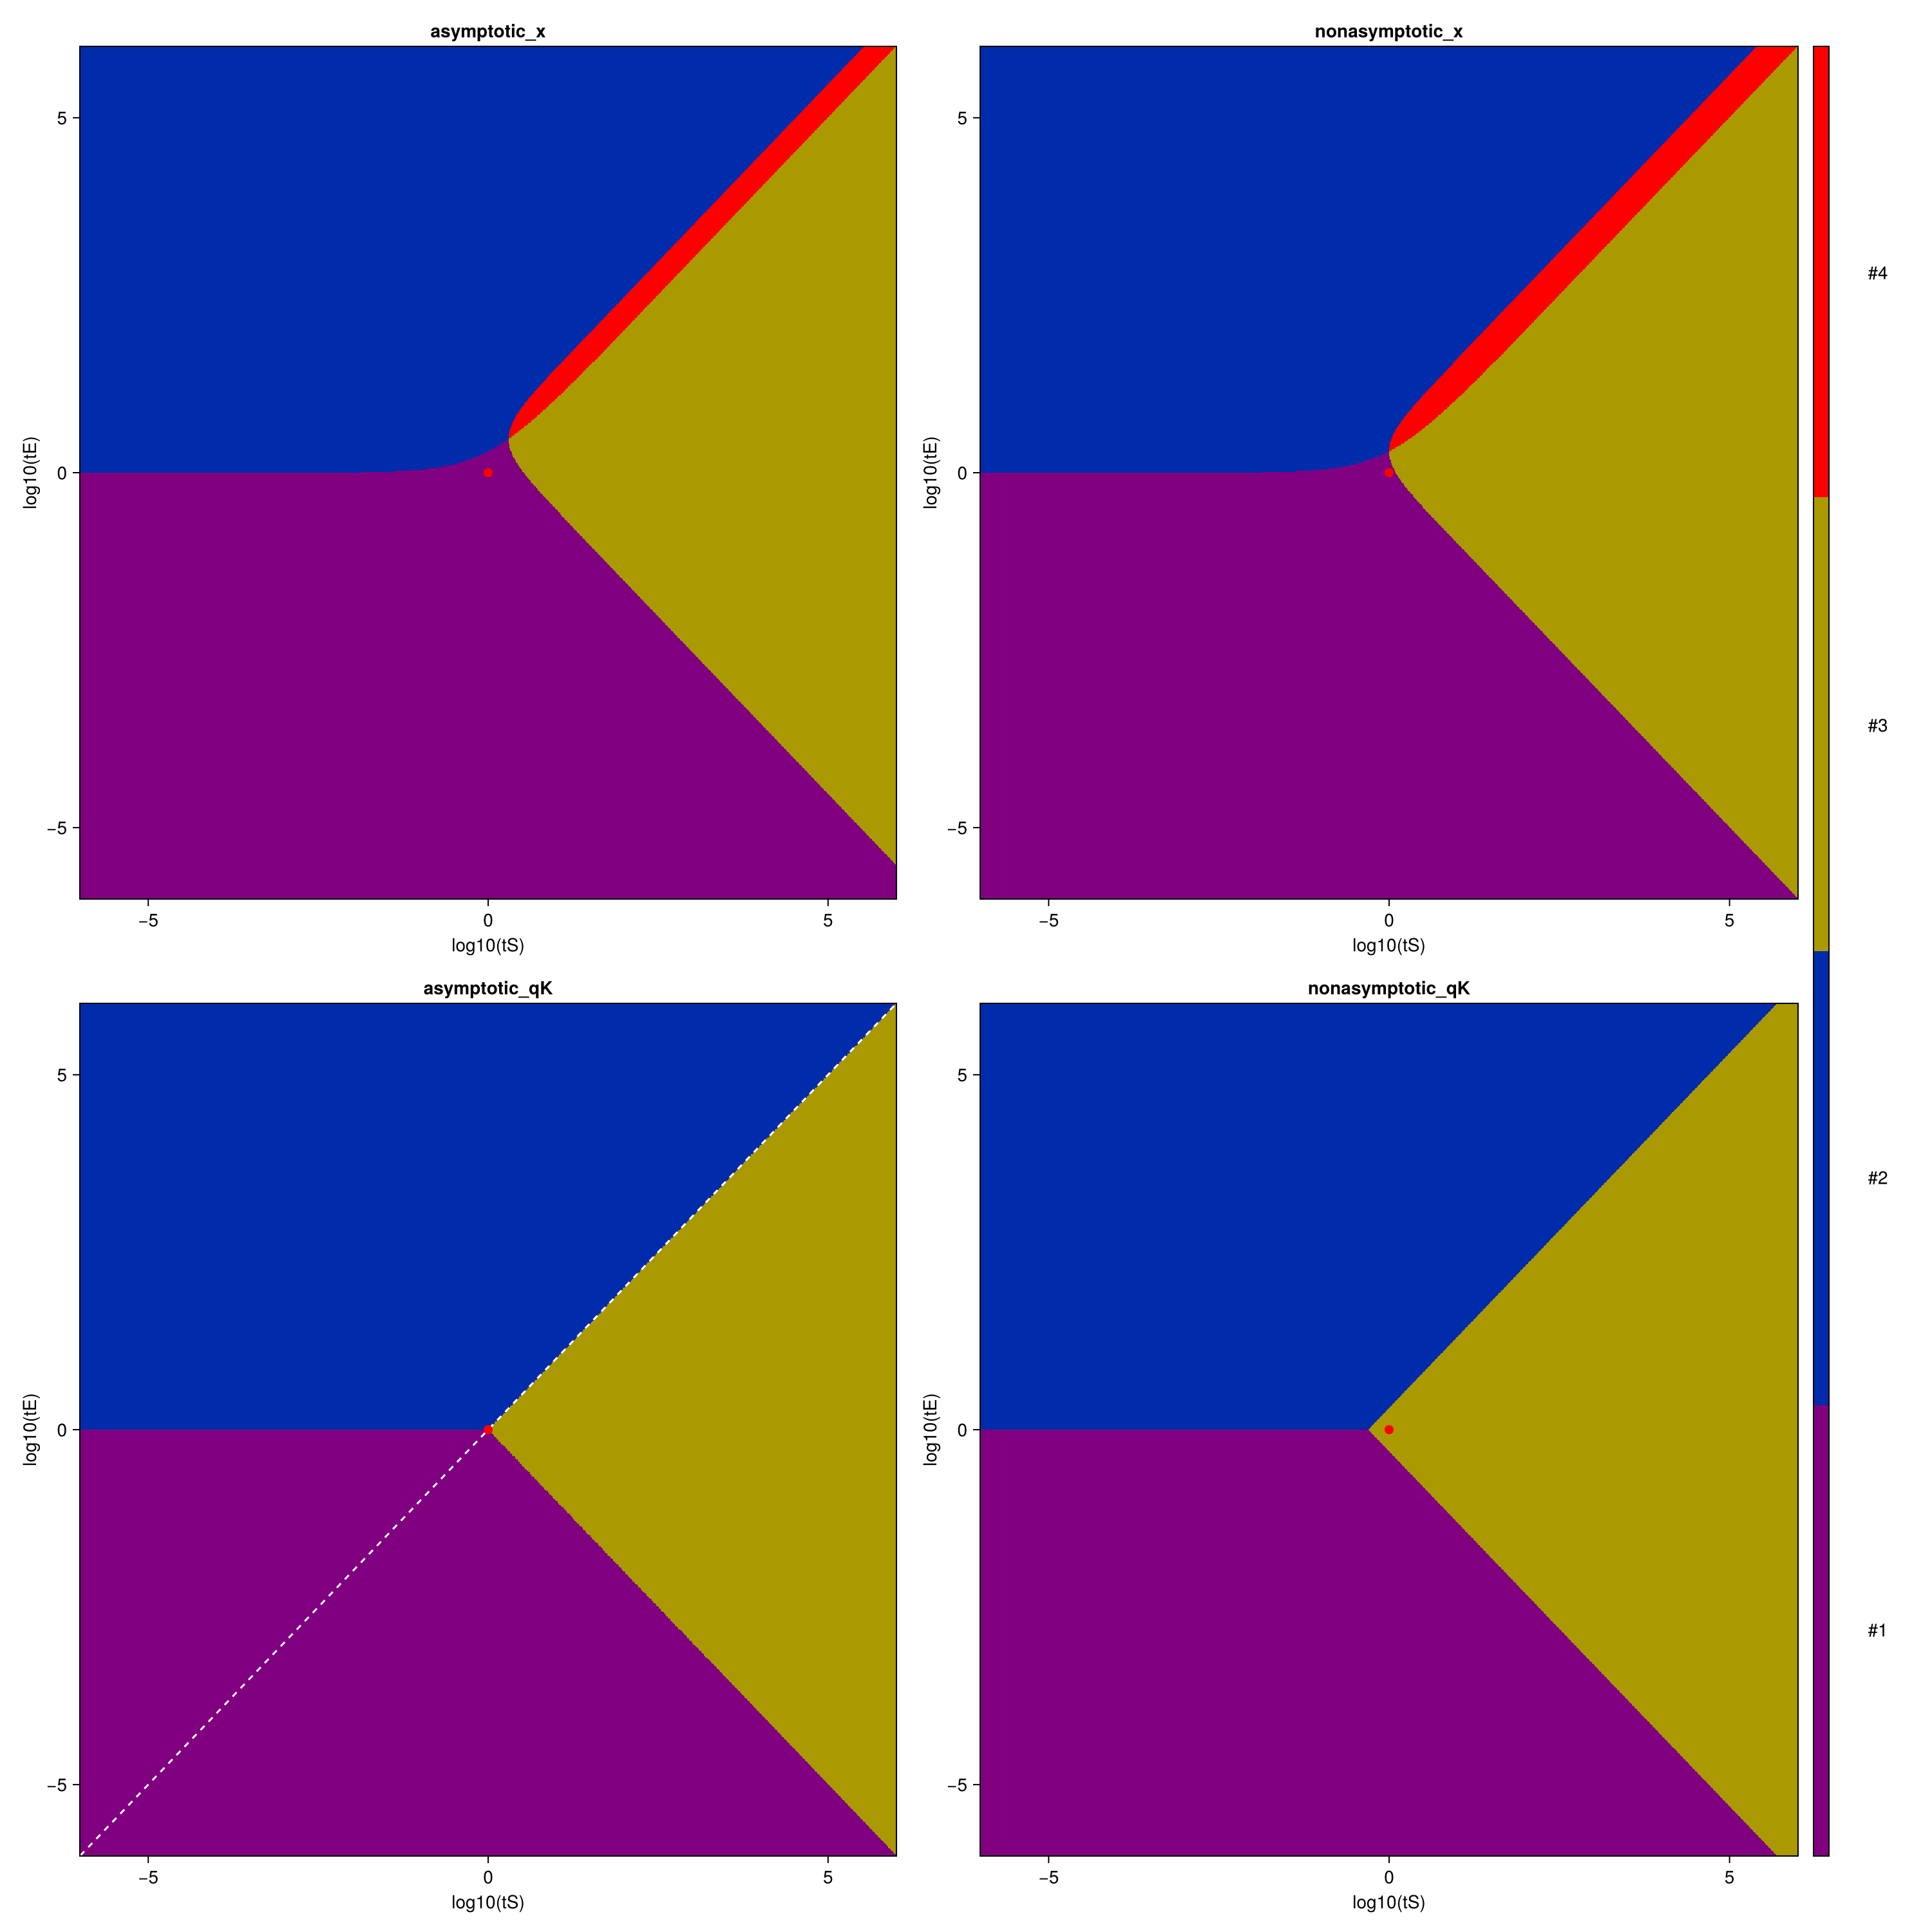

CairoMakie.Screen{IMAGE}


In [20]:
f = Figure(size=(1500,1500))
p1 = Axis(f[1, 1])
p2 = Axis(f[1, 2])
p3 = Axis(f[2, 1])
p4 = Axis(f[2, 2])

# --- Plot 1: asymptotic_x ---
p1.title = "asymptotic_x"
heatmap!(p1, logS_rg, logE_rg, getindex.(Ref(cmap), col_asym_x))
# contour!(p1, logE_rg, logS_rg, bnds_nonasym_x,color = :black)
# --- Plot 2: nonasymptotic_x ---
p2.title = "nonasymptotic_x"
heatmap!(p2, logS_rg, logE_rg, getindex.(Ref(cmap), col_nonasym_x))
# --- Plot 3: asymptotic_qK ---
p3.title = "asymptotic_qK"
heatmap!(p3,  logS_rg, logE_rg, getindex.(Ref(cmap), col_asym_qK))
# contour!(p3, logE_rg, logS_rg, bnds_nonasym_x, color = :black)
lines!(p3, [-6,6], [-6,6], color=:white, linestyle=:dash)

# --- Plot 4: nonasymptotic_qK ---
p4.title = "nonasymptotic_qK"
heatmap!(p4, logS_rg, logE_rg, getindex.(Ref(cmap), col_nonasym_qK))
# contour!(p4, logE_rg, logS_rg, bnds_nonasym_x,color = :black)

for p in [p1, p2, p3, p4]
    # Add the red dot
    scatter!(p, [logK], [logK], marker=:circle, markersize=10, color=:red)
    # Set the axis labels (modern syntax)
    p.xlabel = "log10(tS)"
    p.ylabel = "log10(tE)"
end

add_rgm_colorbar!(f,cmap)

display(f)